# QNNs

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pickle

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification, make_moons, make_circles
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from qiskit_machine_learning.utils import algorithm_globals

import qiskit
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.primitives import StatevectorSampler, StatevectorEstimator as Estimator
from qiskit_algorithms.optimizers import ADAM
from qiskit_machine_learning.algorithms import VQC
from qiskit.quantum_info import SparsePauliOp
from qiskit_machine_learning.neural_networks import EstimatorQNN, EffectiveDimension, LocalEffectiveDimension, SamplerQNN

import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [61]:
# IRIS DATASET
iris = load_iris()
X, y = iris.data, iris.target
mask = y < 2
X_set, y_set = X[mask], y[mask]

X_train, X_test, y_train, y_test = train_test_split(
    X_set, y_set, test_size=0.2, random_state=42
)
scaler  = MinMaxScaler(feature_range=(-np.pi, np.pi))
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

## Functions for QNN

In [1]:
# Parts of the circuits
# FEATURE MAPS
# feature map without entaglement
def EasyFeatureMap(N):
    x = ParameterVector('x', N)
    qc = QuantumCircuit(N)
    for i in range(N):
        qc.h(i)
        qc.rz(x[i], i)
    qc.barrier()
    return qc

# feature with entaglement
def FeatureMap(N):
    x = ParameterVector('x', N)
    qc = QuantumCircuit(N)
    for i in range(N):
        qc.h(i)
        qc.rz(x[i], i)
    for i in range(N):
        for j in range(i):
            qc.cx(j, i)
            qc.rz(x[j] * x[i], i)
            qc.cx(j, i)
        qc.barrier()
    return qc

# --------------------------------------------------------------
# ANSATZ
def Ansatz(n_bits):
    theta = ParameterVector('theta', 2*n_bits)
    qc = QuantumCircuit(n_bits)
    for i in range(n_bits):
        qc.ry(theta[i], i)
    qc.barrier()
    for i in range(n_bits-1):
        for j in range(i+1,n_bits):
            qc.cx(i, j)
    qc.barrier()
    for i in range(n_bits):
        qc.ry(theta[i+n_bits], i)
    return qc

def Ansatz_60_par(n_bits):
    theta = ParameterVector('theta', 15*n_bits)
    qc = QuantumCircuit(n_bits)

    for l in range(15):
        for i in range(n_bits):
            qc.ry(theta[i+l*n_bits], i)
        qc.barrier()
    
        for i in range(n_bits-1):
            for j in range(i+1,n_bits):
                qc.cx(i, j)
        qc.barrier()
    for i in range(n_bits):
        qc.ry(theta[i+l*n_bits], i)
    qc.barrier()

    return qc

# --------------------------------------------------------------
# interpret of the output
def parity(x):
    return "{:b}".format(x).count("1") % 2

# SAMPLER
def make_sampler_qnn(circ):
    x_p     = sorted([p for p in circ.parameters if p.name.startswith('x')],
                      key=lambda p: p.index)
    theta_p = sorted([p for p in circ.parameters if p.name.startswith('theta')],
                      key=lambda p: p.index)
    return SamplerQNN(
        circuit=circ,
        input_params=x_p,
        weight_params=theta_p,
        interpret=parity,
        output_shape=2,
        sampler=StatevectorSampler(),
    )

# QNN Builder
def QNN_builder(n_bits, featureMap, ansatz, depth=1):
    fm = featureMap(n_bits)
    a  = ansatz(n_bits)
    qc = QuantumCircuit(n_bits)
    for i in range(depth):
        qc = qc.compose(fm.copy())
        qc = qc.compose(a.copy())
    return qc

# --------------------------------------------------------------

# Function to get weights for Local ED
def get_trained_weights(feature_map_fn, ansatz_fn, N, x_tr, y_tr, maxiter=80):
    trained_weights_store = []
    def adam_capture(fun, x0, jac=None, **kwargs):
        opt = ADAM(maxiter=maxiter, lr=0.1, beta_1=0.9, beta_2=0.99, tol=1e-8)
        def tracked_jac(w):
            trained_weights_store.append(w.copy())
            return jac(w)
        return opt.minimize(fun=fun, x0=x0, jac=tracked_jac)
    vqc = VQC(
        sampler=StatevectorSampler(),
        feature_map=feature_map_fn(N),
        ansatz=ansatz_fn(N),
        optimizer=adam_capture,
    )
    vqc.fit(x_tr, y_tr)
    return trained_weights_store[-1] if trained_weights_store else vqc.weights

# --------------------------------------------------------------
# Compute Fisher Information Matrix
def compute_fim(eqnn,X,weights):
    outputs = qnn.forward(X, weights)   
    _, grads = qnn.backward(X, weights) 
    d = len(weights)
    F = np.zeros((d, d))
    for i in range(len(X)):
        for k in range(outputs.shape[1]):
            f_k = float(outputs[i, k]) + 1e-10
            g_k = grads[i, k, :]
            F  += np.outer(g_k, g_k) / f_k
    return F / len(X)

# Plot FIM
def plot_fim(ax, fim, label, color, bins=20):
    eigvals = np.linalg.eigvalsh(fim)

    counts, bin_edges = np.histogram(eigvals, bins=bins)
    counts_norm = counts / np.sum(counts)

    ax.bar(bin_edges[:-1], counts_norm,
           width=np.diff(bin_edges),
           color=color, alpha=0.8,
           edgecolor='white', align='edge')
    ax.set_xlabel('Eigenvalue')
    ax.set_ylabel('Normalised counts')
    ax.set_title(f'FIM spectrum — {label}')
    ax.set_ylim([0, 1.05])
    ax.grid(True, axis='y', alpha=0.3)

    from mpl_toolkits.axes_grid1.inset_locator import inset_axes
    ax_inset = inset_axes(ax, width="45%", height="45%", loc='upper right')

    eigvals_zoom = eigvals[eigvals <= 1]
    if len(eigvals_zoom) > 0:
        counts_z, edges_z = np.histogram(eigvals_zoom, bins=15)
        counts_z_norm = counts_z / np.sum(counts_z)
        ax_inset.bar(edges_z[:-1], counts_z_norm,
                     width=np.diff(edges_z),
                     color=color, alpha=0.8,
                     edgecolor='white', align='edge')
    ax_inset.set_xlim([0, 1])
    ax_inset.set_ylim([0, 1.05])
    ax_inset.set_xlabel('', fontsize=7)
    ax_inset.tick_params(labelsize=7)
    ax_inset.grid(True, axis='y', alpha=0.3)
    #ax_inset.set_title('zoom [0,1]', fontsize=7)

In [6]:
SEED       = 42
EPOCHS     = 100
BATCH_SIZE = 16
N          = 4
N_RUNS     = 5
N_ITER     = 100

## Test 8 parameters

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


num_inputs : 4
num_weights: 8
depth QNN=27
CNOT gates: 18
RY gates: 8


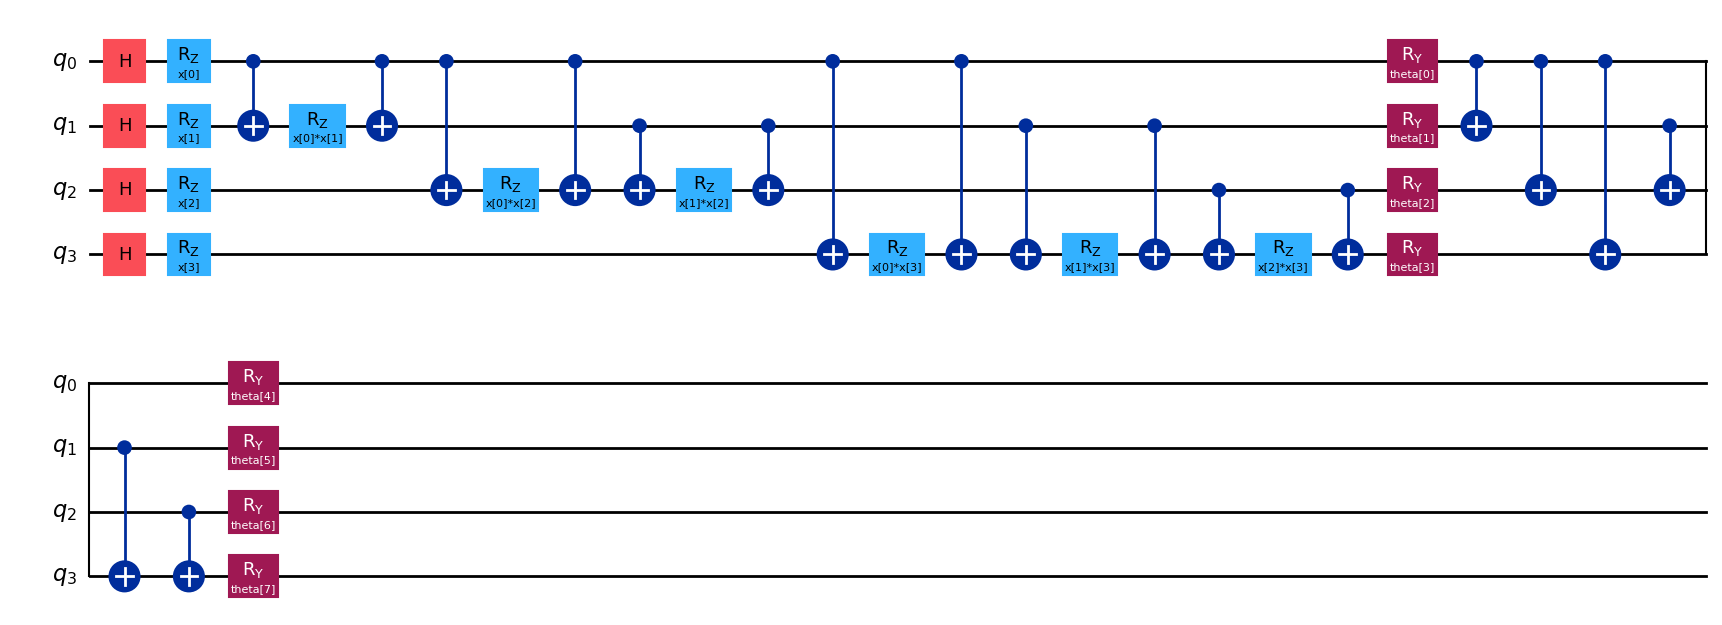

In [12]:
qc = QNN_builder(4,FeatureMap,Ansatz)
qnn_s      = make_sampler_qnn(qc)
d = qnn_s.num_weights   # number of trainable parameters = 2*N
print(f'num_inputs : {qnn_s.num_inputs}')
print(f'num_weights: {d}')
print(f"depth QNN={qc.depth()}")
ops = qc.count_ops()
print(f"CNOT gates: {ops.get('cx', 0)}")
print(f"RY gates: {ops.get('ry', 0)}")

qc.draw("mpl", style="iqp", plot_barriers=False)

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


num_inputs : 4
num_weights: 8
depth QNN=9
CNOT gates: 6
RY gates: 8


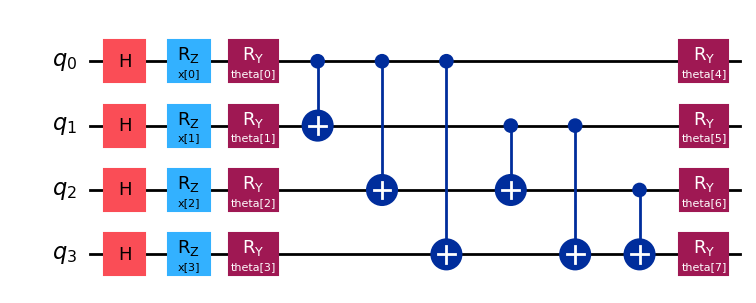

In [14]:
easy_qc = QNN_builder(4,EasyFeatureMap,Ansatz)
qnn_s_easy = make_sampler_qnn(easy_qc)
d_s = qnn_s_easy.num_weights   # number of trainable parameters = 2*N
print(f'num_inputs : {qnn_s_easy.num_inputs}')
print(f'num_weights: {d_s}')
print(f"depth QNN={easy_qc.depth()}")
ops = easy_qc.count_ops()
print(f"CNOT gates: {ops.get('cx', 0)}")
print(f"RY gates: {ops.get('ry', 0)}")

easy_qc.draw("mpl", style="iqp", plot_barriers=False)

In [ ]:
algorithm_globals.random_seed = 42

n = [5000, 8000, 10000, 40000, 60000, 100000, 150000, 200000, 500000, 1000000]

# ── 1. Global ED ──────────────────────────────────────────────
global_ed_qnn  = EffectiveDimension(qnn=qnn_s,      weight_samples=50, input_samples=50)
global_ed_easy = EffectiveDimension(qnn=qnn_s_easy, weight_samples=50, input_samples=50)

global_eff_qnn  = global_ed_qnn.get_effective_dimension(dataset_size=n)
global_eff_easy = global_ed_easy.get_effective_dimension(dataset_size=n)

print(f'Global ED QNN  (n=5000): {global_eff_qnn[0]:.4f}  normalized: {global_eff_qnn[0]/d:.4f}')
print(f'Global ED easy (n=5000): {global_eff_easy[0]:.4f}  normalized: {global_eff_easy[0]/d:.4f}')

# ── 2. Local ED ───────────────────────────────────────────────
untrained_weights = algorithm_globals.random.uniform(0, 2 * np.pi, d)

print('Training QNN for local ED...')
trained_weights_qnn  = get_trained_weights(FeatureMap,     Ansatz, N, X_train, y_train)
print('Training easy QNN for local ED...')
trained_weights_easy = get_trained_weights(EasyFeatureMap, Ansatz, N, X_train, y_train)

local_ed_trained_qnn    = LocalEffectiveDimension(qnn=qnn_s,      weight_samples=trained_weights_qnn,  input_samples=X_train)
local_ed_untrained_qnn  = LocalEffectiveDimension(qnn=qnn_s,      weight_samples=untrained_weights,    input_samples=X_train)
local_ed_trained_easy   = LocalEffectiveDimension(qnn=qnn_s_easy, weight_samples=trained_weights_easy, input_samples=X_train)
local_ed_untrained_easy = LocalEffectiveDimension(qnn=qnn_s_easy, weight_samples=untrained_weights,    input_samples=X_train)

local_eff_trained_qnn    = local_ed_trained_qnn.get_effective_dimension(dataset_size=n)
local_eff_untrained_qnn  = local_ed_untrained_qnn.get_effective_dimension(dataset_size=n)
local_eff_trained_easy   = local_ed_trained_easy.get_effective_dimension(dataset_size=n)
local_eff_untrained_easy = local_ed_untrained_easy.get_effective_dimension(dataset_size=n)

# ── 3. FIM ────────────────────────────────────────────────────
fim_trained_qnn    = compute_fim(local_ed_trained_qnn)
fim_untrained_qnn  = compute_fim(local_ed_untrained_qnn)
fim_trained_easy   = compute_fim(local_ed_trained_easy)
fim_untrained_easy = compute_fim(local_ed_untrained_easy)

print(f'FIM trace QNN     trained: {np.trace(fim_trained_qnn):.4f}')
print(f'FIM trace QNN   untrained: {np.trace(fim_untrained_qnn):.4f}')
print(f'FIM trace easy    trained: {np.trace(fim_trained_easy):.4f}')
print(f'FIM trace easy  untrained: {np.trace(fim_untrained_easy):.4f}')

Global ED QNN       (n=5000): 7.0586  normalized: 0.8823
Global ED easy      (n=5000): 5.7568  normalized: 0.7196
Local trained ED QNN  (n=5000): 7.5252  normalized: 0.9406
Local trained ED easy (n=5000): 6.1394  normalized: 0.7674
FIM trace QNN     trained: 0.3869
FIM trace QNN   untrained: 0.3457
FIM trace easy    trained: 0.3338
FIM trace easy  untrained: 0.2976


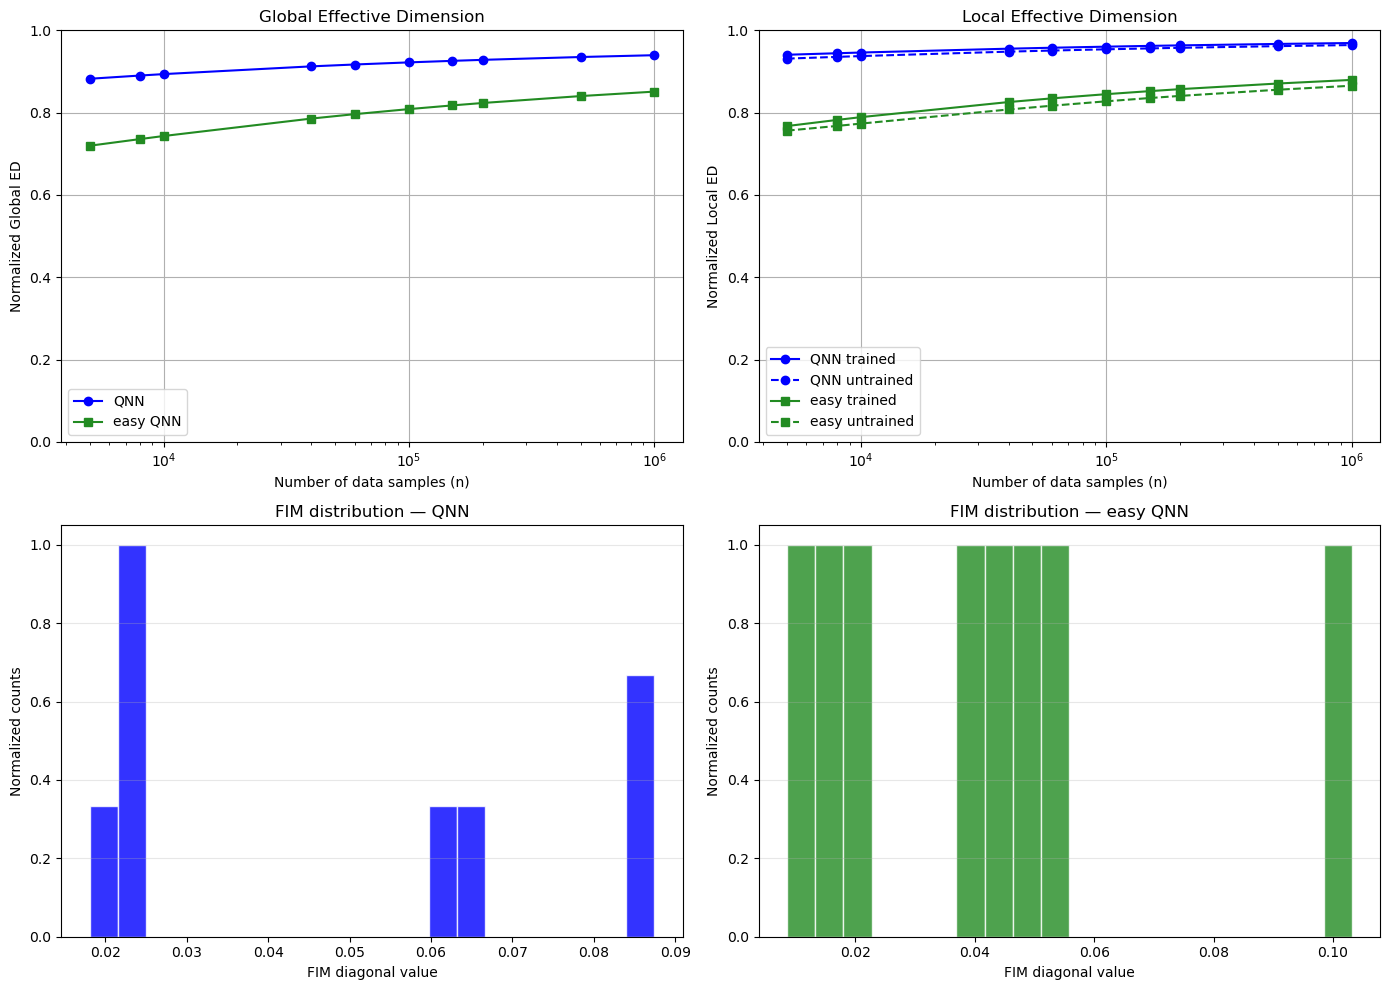

In [9]:
n = [5000, 8000, 10000, 40000, 60000, 100000, 150000, 200000, 500000, 1000000]

global_eff_qnn           = np.load('ED/global_eff_qnn.pkl',           allow_pickle=True)
global_eff_easy          = np.load('ED/global_eff_easy.pkl',           allow_pickle=True)
local_eff_trained_qnn    = np.load('ED/local_eff_trained_qnn.pkl',     allow_pickle=True)
local_eff_trained_easy   = np.load('ED/local_eff_trained_easy.pkl',    allow_pickle=True)
local_eff_untrained_qnn  = np.load('ED/local_eff_untrained_qnn.pkl',   allow_pickle=True)
local_eff_untrained_easy = np.load('ED/local_eff_untrained_easy.pkl',  allow_pickle=True)
fim_trained_qnn          = np.load('ED/fim_trained_qnn.pkl',           allow_pickle=True)
fim_trained_easy         = np.load('ED/fim_trained_easy.pkl',          allow_pickle=True)
fim_untrained_qnn        = np.load('ED/fim_untrained_qnn.pkl',         allow_pickle=True)
fim_untrained_easy       = np.load('ED/fim_untrained_easy.pkl',        allow_pickle=True)

d = fim_trained_qnn.shape[0]

print(f'Global ED QNN       (n=5000): {global_eff_qnn[0]:.4f}  normalized: {global_eff_qnn[0]/d:.4f}')
print(f'Global ED easy      (n=5000): {global_eff_easy[0]:.4f}  normalized: {global_eff_easy[0]/d:.4f}')
print(f'Local trained ED QNN  (n=5000): {local_eff_trained_qnn[0]:.4f}  normalized: {local_eff_trained_qnn[0]/d:.4f}')
print(f'Local trained ED easy (n=5000): {local_eff_trained_easy[0]:.4f}  normalized: {local_eff_trained_easy[0]/d:.4f}')
print(f'FIM trace QNN     trained: {np.trace(fim_trained_qnn):.4f}')
print(f'FIM trace QNN   untrained: {np.trace(fim_untrained_qnn):.4f}')
print(f'FIM trace easy    trained: {np.trace(fim_trained_easy):.4f}')
print(f'FIM trace easy  untrained: {np.trace(fim_untrained_easy):.4f}')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Global ED
axes[0,0].plot(n, np.array(global_eff_qnn)  / d, marker='o', color='blue',        label='QNN')
axes[0,0].plot(n, np.array(global_eff_easy) / d, marker='s', color='forestgreen', label='easy QNN')
axes[0,0].set_xscale('log')
axes[0,0].set_ylim([0, 1])
axes[0,0].set_xlabel('Number of data samples (n)')
axes[0,0].set_ylabel('Normalized Global ED')
axes[0,0].set_title('Global Effective Dimension')
axes[0,0].legend()
axes[0,0].grid(True)

# Local ED
axes[0,1].plot(n, np.array(local_eff_trained_qnn)   / d, color='blue',        marker='o', label='QNN trained')
axes[0,1].plot(n, np.array(local_eff_untrained_qnn) / d, color='blue',        marker='o', label='QNN untrained',  linestyle='--')
axes[0,1].plot(n, np.array(local_eff_trained_easy)  / d, color='forestgreen', marker='s', label='easy trained')
axes[0,1].plot(n, np.array(local_eff_untrained_easy)/ d, color='forestgreen', marker='s', label='easy untrained', linestyle='--')
axes[0,1].set_xscale('log')
axes[0,1].set_ylim([0, 1])
axes[0,1].set_xlabel('Number of data samples (n)')
axes[0,1].set_ylabel('Normalized Local ED')
axes[0,1].set_title('Local Effective Dimension')
axes[0,1].legend()
axes[0,1].grid(True)

# FIM — usa plot_fim
plot_fim(axes[1,0], fim_trained_qnn,  label='QNN',     color='blue')
plot_fim(axes[1,1], fim_trained_easy, label='easy QNN', color='forestgreen')

plt.tight_layout()
plt.show()


# QNN 60 Parameters

In [58]:
qc = QNN_builder(4,FeatureMap,Ansatz_60_par)
qnn_s      = make_sampler_qnn(qc)
d = qnn_s.num_weights
print(f'QNN')
print(f'num_inputs : {qnn_s.num_inputs}')
print(f'num_weights: {d}')
print(f"depth QNN={qc.depth()}")
ops = qc.count_ops()
print(f"CNOT gates: {ops.get('cx', 0)}")
print(f"RY gates: {ops.get('ry', 0)}")

print('----------------------\nEasy QNN')
easy_qc = QNN_builder(4,EasyFeatureMap,Ansatz_60_par)
qnn_s_easy = make_sampler_qnn(easy_qc)
d_s = qnn_s_easy.num_weights
print(f'num_inputs : {qnn_s_easy.num_inputs}')
print(f'num_weights: {d_s}')
print(f"depth QNN={easy_qc.depth()}")
ops = easy_qc.count_ops()
print(f"CNOT gates: {ops.get('cx', 0)}")
print(f"RY gates: {ops.get('ry', 0)}")

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


QNN
num_inputs : 4
num_weights: 60
depth QNN=111
CNOT gates: 102
RY gates: 64
----------------------
Easy QNN
num_inputs : 4
num_weights: 60
depth QNN=93
CNOT gates: 90
RY gates: 64


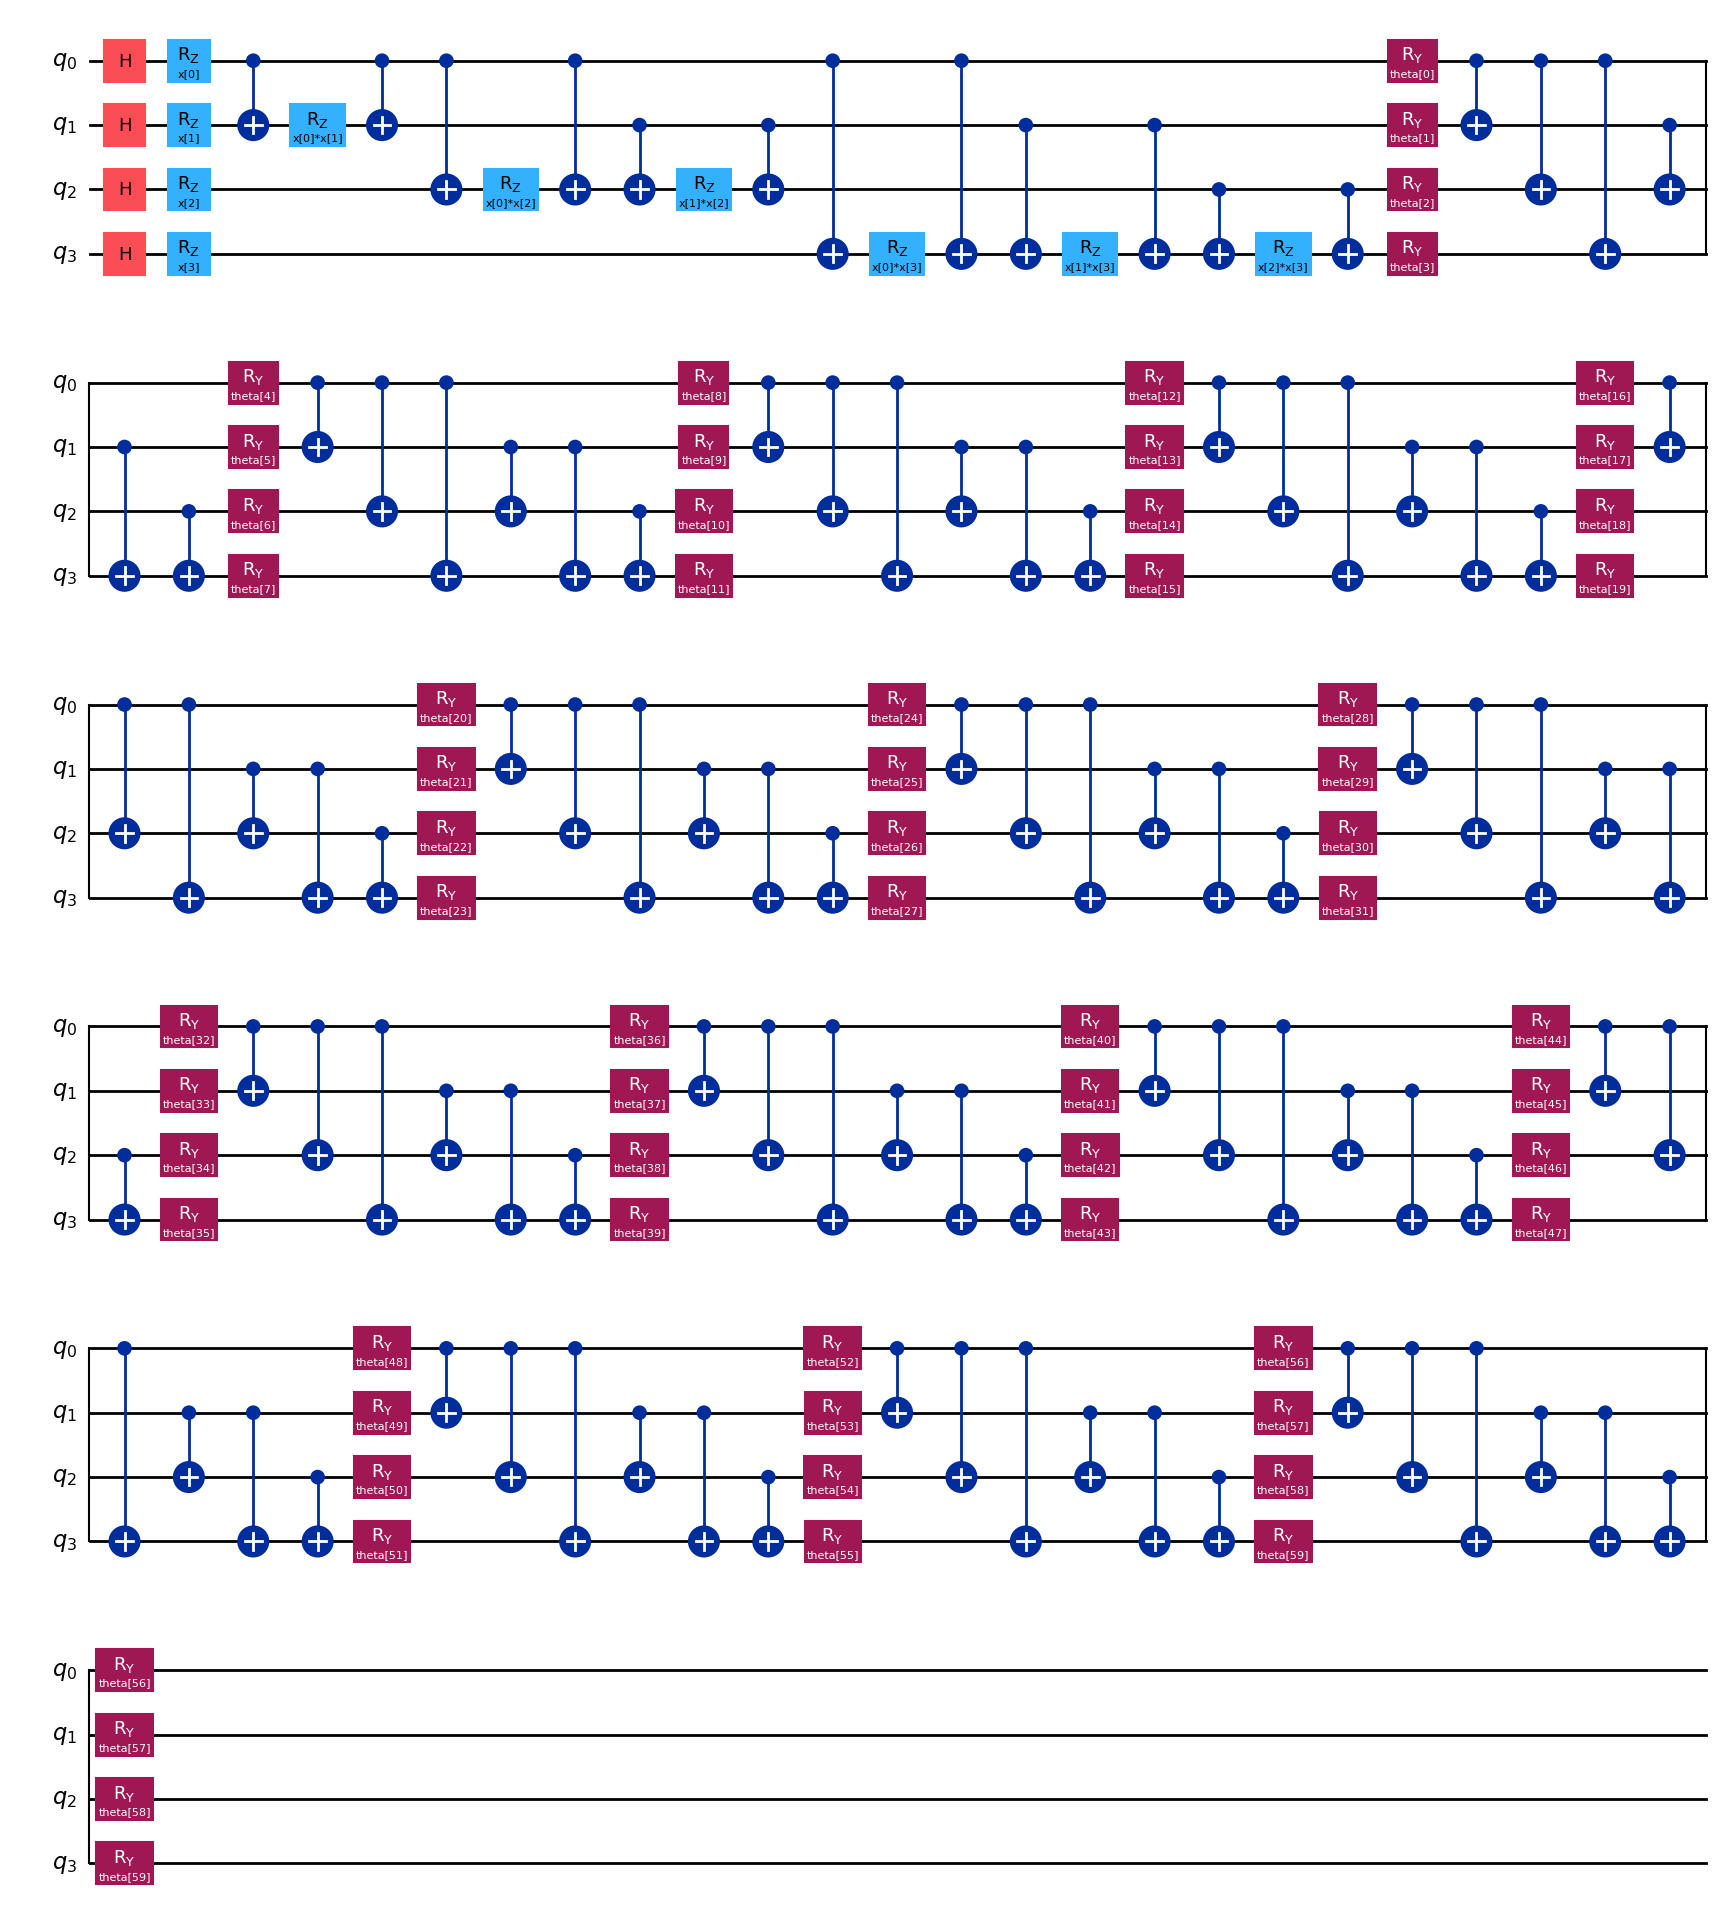

In [59]:
qc.draw("mpl", style="iqp", plot_barriers=False)

In [ ]:
# -- 1. Global ED ----------------------------------------------
global_ed_qnn  = EffectiveDimension(qnn=qnn_s,      weight_samples=200, input_samples=100)
global_ed_easy = EffectiveDimension(qnn=qnn_s_easy, weight_samples=200, input_samples=100)

global_eff_qnn  = global_ed_qnn.get_effective_dimension(dataset_size=n)
global_eff_easy = global_ed_easy.get_effective_dimension(dataset_size=n)

print(f'Global ED QNN  (n=5000): {global_eff_qnn[0]:.4f}  normalized: {global_eff_qnn[0]/d:.4f}')
print(f'Global ED easy (n=5000): {global_eff_easy[0]:.4f}  normalized: {global_eff_easy[0]/d:.4f}')

# -- 2. Local ED ----------------------------------------------

print('Training QNN for local ED...')
trained_weights_qnn  = get_trained_weights(FeatureMap,     Ansatz_60_par, N, X_train, y_train)
print('Training easy QNN for local ED...')
trained_weights_easy = get_trained_weights(EasyFeatureMap, Ansatz_60_par, N, X_train, y_train)

local_ed_trained_qnn    = LocalEffectiveDimension(qnn=qnn_s,      weight_samples=trained_weights_qnn,  input_samples=X_train)
local_ed_trained_easy   = LocalEffectiveDimension(qnn=qnn_s_easy, weight_samples=trained_weights_easy, input_samples=X_train)

local_eff_trained_qnn    = local_ed_trained_qnn.get_effective_dimension(dataset_size=n)
local_eff_trained_easy   = local_ed_trained_easy.get_effective_dimension(dataset_size=n)

# -- 3. FIM ----------------------------------------------
fim_trained_qnn    = compute_fim(qnn_s, X_train, trained_weights_qnn)
fim_trained_easy   = compute_fim(qnn_s_easy, X_train, trained_weights_easy)

print(f'FIM trace QNN     trained: {np.trace(fim_trained_qnn):.4f}')
print(f'FIM trace easy    trained: {np.trace(fim_trained_easy):.4f}')

# -------------------------------------------------------------
# SAVE FILES
# Effective Dimension
with open("4_qubits/global_eff_qnn.pkl", "wb") as f:
    pickle.dump(global_eff_qnn, f)
with open("4_qubits/global_eff_easy.pkl", "wb") as f:
    pickle.dump(global_eff_easy, f)
with open("4_qubits/local_eff_trained_qnn.pkl", "wb") as f:
    pickle.dump(local_eff_trained_qnn, f)
with open("4_qubits/local_eff_trained_easy.pkl", "wb") as f:
    pickle.dump(local_eff_trained_easy, f)

# Fisher Information
with open("4_qubits/fim_trained_qnn.pkl", "wb") as f:
    pickle.dump(fim_trained_qnn, f)
with open("4_qubits/fim_trained_easy.pkl", "wb") as f:
    pickle.dump(fim_trained_easy, f)

/tmp/ipykernel_6710/3586672052.py:11: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


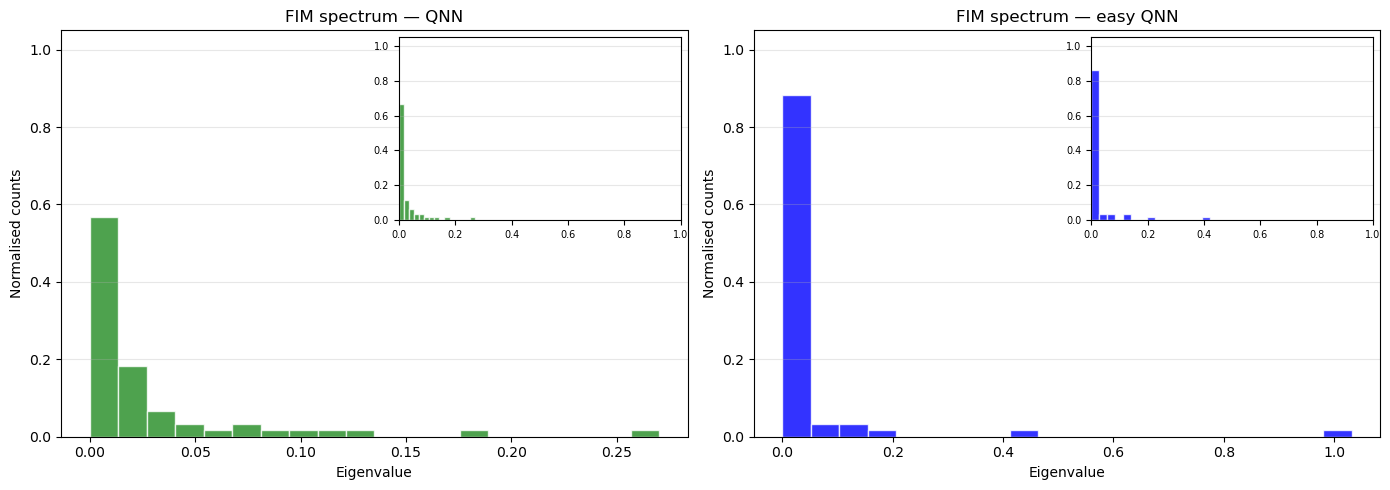

In [167]:
fim_trained_qnn  = np.load('4_qb/fim_qnn.pkl',  allow_pickle=True)
fim_trained_easy = np.load('4_qb/fim_easy_qnn.pkl', allow_pickle=True)

d = fim_trained_qnn.shape[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_fim(axes[0], fim_trained_qnn,  label='QNN',     color='forestgreen')
plot_fim(axes[1], fim_trained_easy, label='easy QNN', color='blue')

plt.tight_layout()
plt.savefig('fim_histogram_bin.png', dpi=300, bbox_inches='tight')
plt.show()


Global ED QNN       (n=5000): 36.1946  normalized: 0.6032
Global ED easy      (n=5000): 26.6469  normalized: 0.4441
Local trained ED QNN  (n=5000): 40.1836  normalized: 0.6697
Local trained ED easy (n=5000): 21.7877  normalized: 0.3631
FIM trace QNN     trained: 1.6463
FIM trace easy    trained: 2.2439


/tmp/ipykernel_6710/1434619502.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


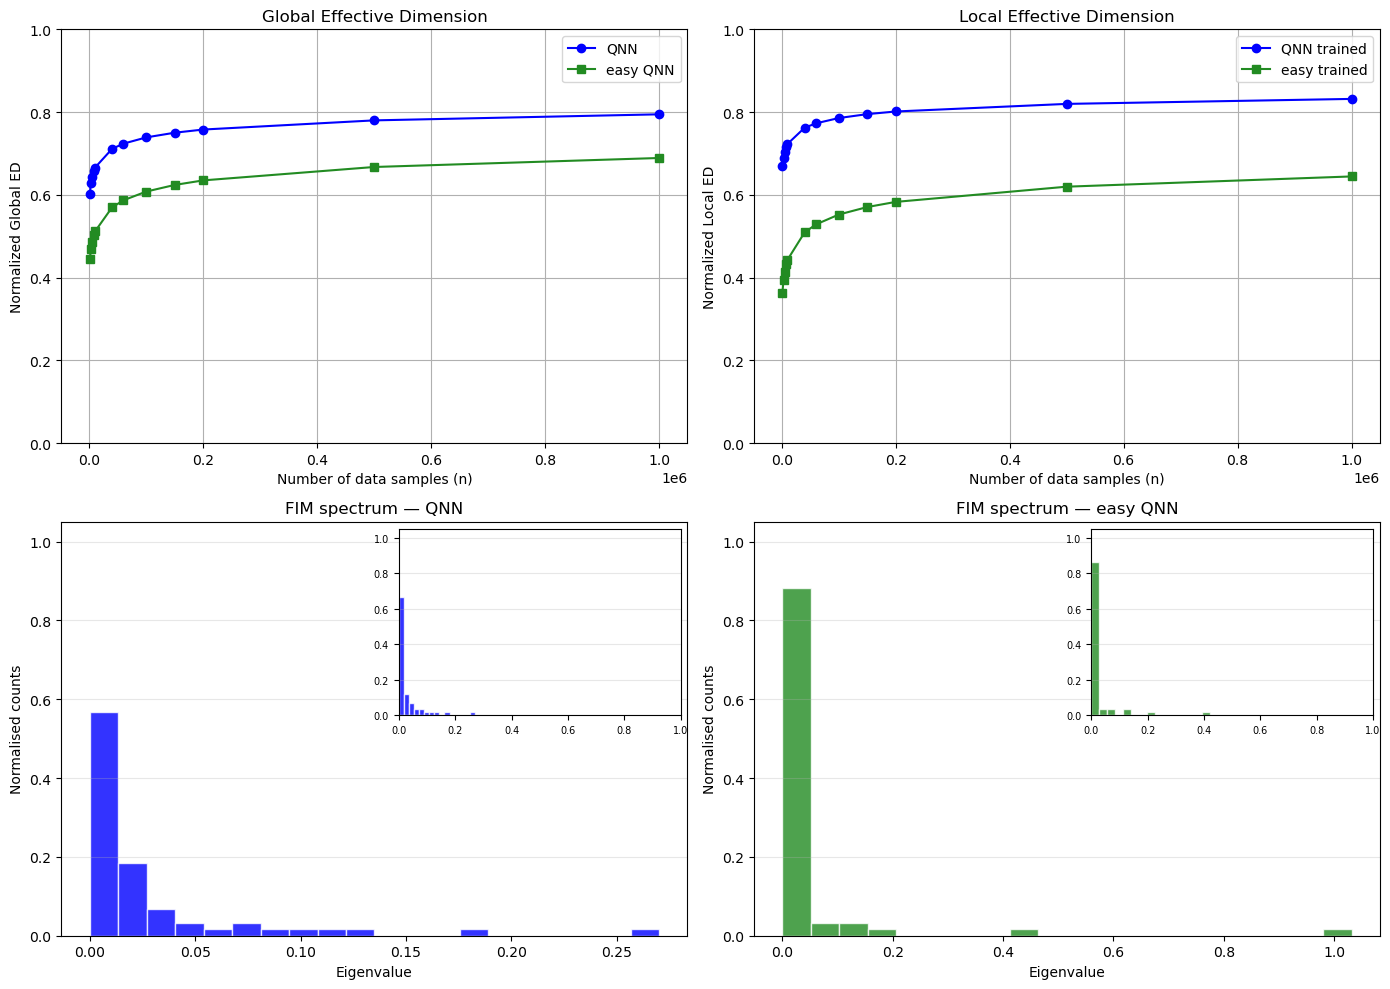

In [168]:
n = [1000,3000,5000, 8000, 10000, 40000, 60000, 100000, 150000, 200000, 500000, 1000000]

global_eff_qnn           = np.load('4_qb/global_eff_qnn.pkl',            allow_pickle=True)
global_eff_easy          = np.load('4_qb/global_eff_easy_qnn.pkl',           allow_pickle=True)
local_eff_trained_qnn    = np.load('4_qb/local_eff_qnn.pkl',     allow_pickle=True)
local_eff_trained_easy   = np.load('4_qb/local_eff_easy_qnn.pkl',    allow_pickle=True)
fim_trained_qnn          = np.load('4_qb/fim_qnn.pkl',           allow_pickle=True)
fim_trained_easy         = np.load('4_qb/fim_easy_qnn.pkl',          allow_pickle=True)

d = fim_trained_qnn.shape[0]   

print(f'Global ED QNN       (n=5000): {global_eff_qnn[0]:.4f}  normalized: {global_eff_qnn[0]/d:.4f}')
print(f'Global ED easy      (n=5000): {global_eff_easy[0]:.4f}  normalized: {global_eff_easy[0]/d:.4f}')
print(f'Local trained ED QNN  (n=5000): {local_eff_trained_qnn[0]:.4f}  normalized: {local_eff_trained_qnn[0]/d:.4f}')
print(f'Local trained ED easy (n=5000): {local_eff_trained_easy[0]:.4f}  normalized: {local_eff_trained_easy[0]/d:.4f}')
print(f'FIM trace QNN     trained: {np.trace(fim_trained_qnn):.4f}')
print(f'FIM trace easy    trained: {np.trace(fim_trained_easy):.4f}')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Global ED
axes[0,0].plot(n, np.array(global_eff_qnn)  / d, marker='o', color='blue',        label='QNN')
axes[0,0].plot(n, np.array(global_eff_easy) / d, marker='s', color='forestgreen', label='easy QNN')
#axes[0,0].set_xscale('log')
axes[0,0].set_ylim([0, 1])
axes[0,0].set_xlabel('Number of data samples (n)')
axes[0,0].set_ylabel('Normalized Global ED')
axes[0,0].set_title('Global Effective Dimension')
axes[0,0].legend()
axes[0,0].grid(True)

# Local ED
axes[0,1].plot(n, np.array(local_eff_trained_qnn)   / d, color='blue',        marker='o', label='QNN trained')
axes[0,1].plot(n, np.array(local_eff_trained_easy)  / d, color='forestgreen', marker='s', label='easy trained')
#axes[0,1].set_xscale('log')
axes[0,1].set_ylim([0, 1])
axes[0,1].set_xlabel('Number of data samples (n)')
axes[0,1].set_ylabel('Normalized Local ED')
axes[0,1].set_title('Local Effective Dimension')
axes[0,1].legend()
axes[0,1].grid(True)

# FIM — usa plot_fim
plot_fim(axes[1,0], fim_trained_qnn,  label='QNN',     color='blue')
plot_fim(axes[1,1], fim_trained_easy, label='easy QNN', color='forestgreen')

plt.tight_layout()
plt.show()


# USING 2 QUBITS

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


num_inputs : 2
num_weights: 60
depth QNN=66
CNOT gates: 32
RY gates: 62


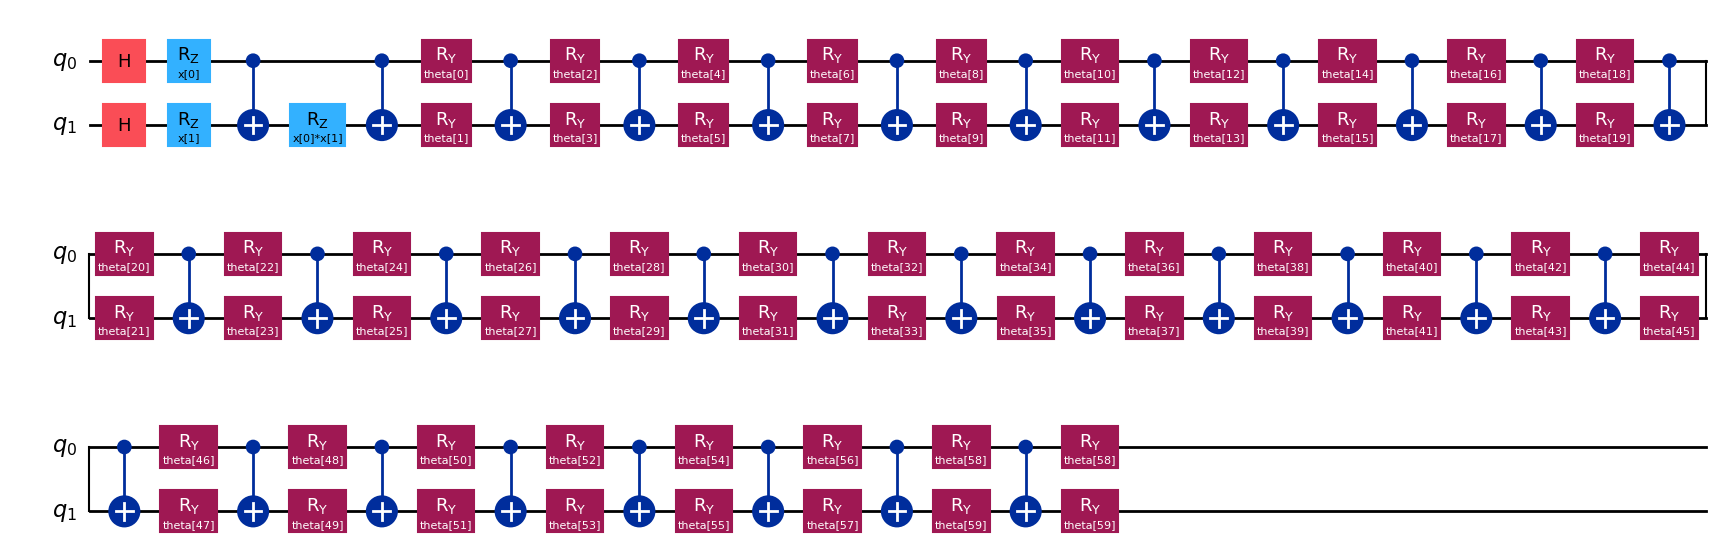

In [171]:
def Ansatz_60_par_2(n_bits):
    theta = ParameterVector('theta', 30*n_bits)
    qc = QuantumCircuit(n_bits)

    for l in range(30):
        for i in range(n_bits):
            qc.ry(theta[i+l*n_bits], i)
        qc.barrier()
    
        for i in range(n_bits-1):
            for j in range(i+1,n_bits):
                qc.cx(i, j)
        qc.barrier()
    for i in range(n_bits):
        qc.ry(theta[i+l*n_bits], i)
    qc.barrier()

    return qc
qc = QNN_builder(2,FeatureMap,Ansatz_60_par_2)
qnn_s      = make_sampler_qnn(qc)
d = qnn_s.num_weights
print(f'num_inputs : {qnn_s.num_inputs}')
print(f'num_weights: {d}')
print(f"depth QNN={qc.depth()}")
ops = qc.count_ops()
print(f"CNOT gates: {ops.get('cx', 0)}")
print(f"RY gates: {ops.get('ry', 0)}")

qc.draw("mpl", style="iqp", plot_barriers=False)

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


num_inputs : 2
num_weights: 60
depth QNN=63
CNOT gates: 30
RY gates: 62


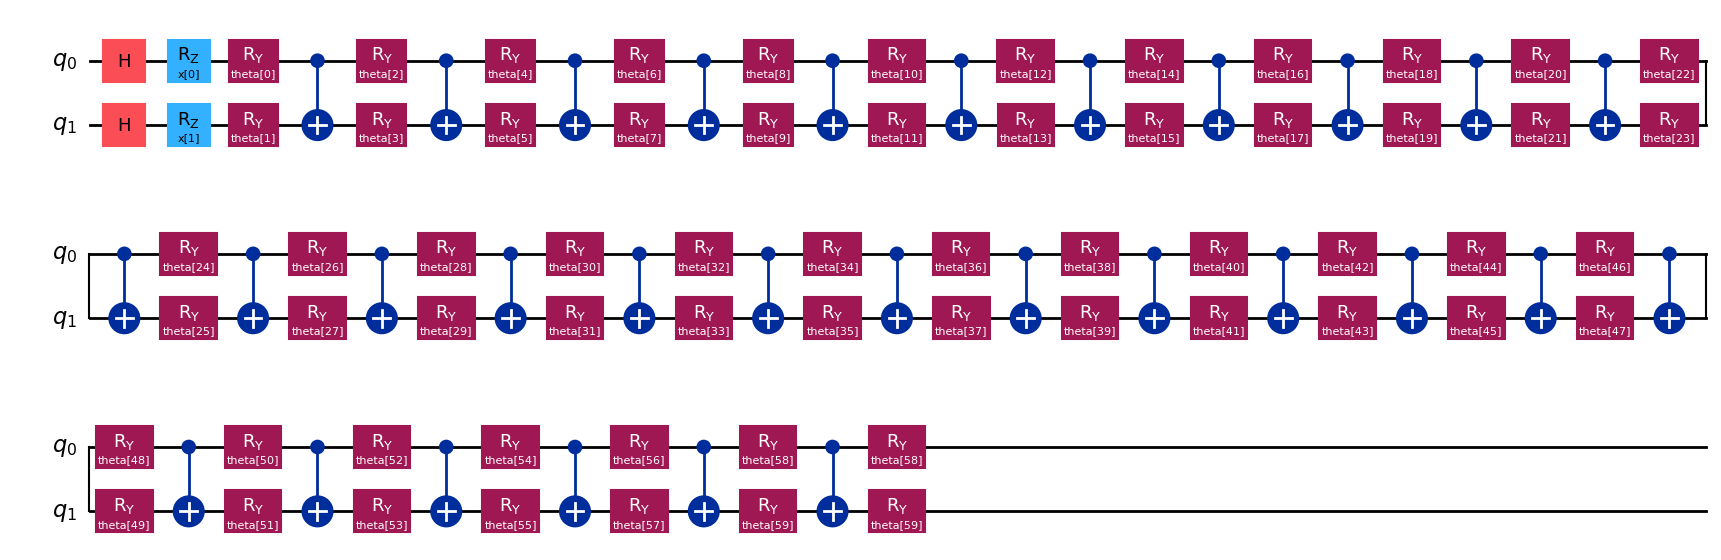

In [172]:
easy_qc = QNN_builder(2,EasyFeatureMap,Ansatz_60_par_2)
qnn_s_easy = make_sampler_qnn(easy_qc)
d_s = qnn_s_easy.num_weights
print(f'num_inputs : {qnn_s_easy.num_inputs}')
print(f'num_weights: {d_s}')
print(f"depth QNN={easy_qc.depth()}")
ops = easy_qc.count_ops()
print(f"CNOT gates: {ops.get('cx', 0)}")
print(f"RY gates: {ops.get('ry', 0)}")
easy_qc.draw("mpl", style="iqp", plot_barriers=False)

In [ ]:
# -- 1. Global ED ----------------------------------------------
global_ed_qnn  = EffectiveDimension(qnn=qnn_s,      weight_samples=200, input_samples=100)
global_ed_easy = EffectiveDimension(qnn=qnn_s_easy, weight_samples=200, input_samples=100)

global_eff_qnn  = global_ed_qnn.get_effective_dimension(dataset_size=n)
global_eff_easy = global_ed_easy.get_effective_dimension(dataset_size=n)

print(f'Global ED QNN  (n=5000): {global_eff_qnn[0]:.4f}  normalized: {global_eff_qnn[0]/d:.4f}')
print(f'Global ED easy (n=5000): {global_eff_easy[0]:.4f}  normalized: {global_eff_easy[0]/d:.4f}')

# -- 2. Local ED ----------------------------------------------
print('Training QNN for local ED...')
trained_weights_qnn  = get_trained_weights(FeatureMap,     Ansatz_60_par_2, N, X_train, y_train)
print('Training easy QNN for local ED...')
trained_weights_easy = get_trained_weights(EasyFeatureMap, Ansatz_60_par_2, N, X_train, y_train)

local_ed_trained_qnn    = LocalEffectiveDimension(qnn=qnn_s,      weight_samples=trained_weights_qnn,  input_samples=X_train)
local_ed_trained_easy   = LocalEffectiveDimension(qnn=qnn_s_easy, weight_samples=trained_weights_easy, input_samples=X_train)

local_eff_trained_qnn    = local_ed_trained_qnn.get_effective_dimension(dataset_size=n)
local_eff_trained_easy   = local_ed_trained_easy.get_effective_dimension(dataset_size=n)

# -- 3. FIM ----------------------------------------------
fim_trained_qnn    = compute_fim(qnn_s, X_train, trained_weights_qnn)
fim_trained_easy   = compute_fim(qnn_s_easy, X_train, trained_weights_easy)

print(f'FIM trace QNN     trained: {np.trace(fim_trained_qnn):.4f}')
print(f'FIM trace easy    trained: {np.trace(fim_trained_easy):.4f}')

# -------------------------------------------------------------
# SAVE FILES
# Effective Dimension
with open("2_qubits/global_eff_qnn.pkl", "wb") as f:
    pickle.dump(global_eff_qnn, f)
with open("2_qubits/global_eff_easy.pkl", "wb") as f:
    pickle.dump(global_eff_easy, f)
with open("2_qubits/local_eff_trained_qnn.pkl", "wb") as f:
    pickle.dump(local_eff_trained_qnn, f)
with open("2_qubits/local_eff_trained_easy.pkl", "wb") as f:
    pickle.dump(local_eff_trained_easy, f)

# Fisher Information
with open("2_qubits/fim_trained_qnn.pkl", "wb") as f:
    pickle.dump(fim_trained_qnn, f)
with open("2_qubits/fim_trained_easy.pkl", "wb") as f:
    pickle.dump(fim_trained_easy, f)

Results 2 qubits ----------------------------
Global ED QNN       (n=5000): 6.6429  normalized: 0.2214
Global ED easy      (n=5000): 6.5607  normalized: 0.2187
Local trained ED QNN  (n=5000): 7.5994  normalized: 0.2533
Local trained ED easy (n=5000): 6.1816  normalized: 0.2061
FIM trace QNN     trained: 8.3709
FIM trace easy    trained: 8.4195


/tmp/ipykernel_12003/3697256130.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


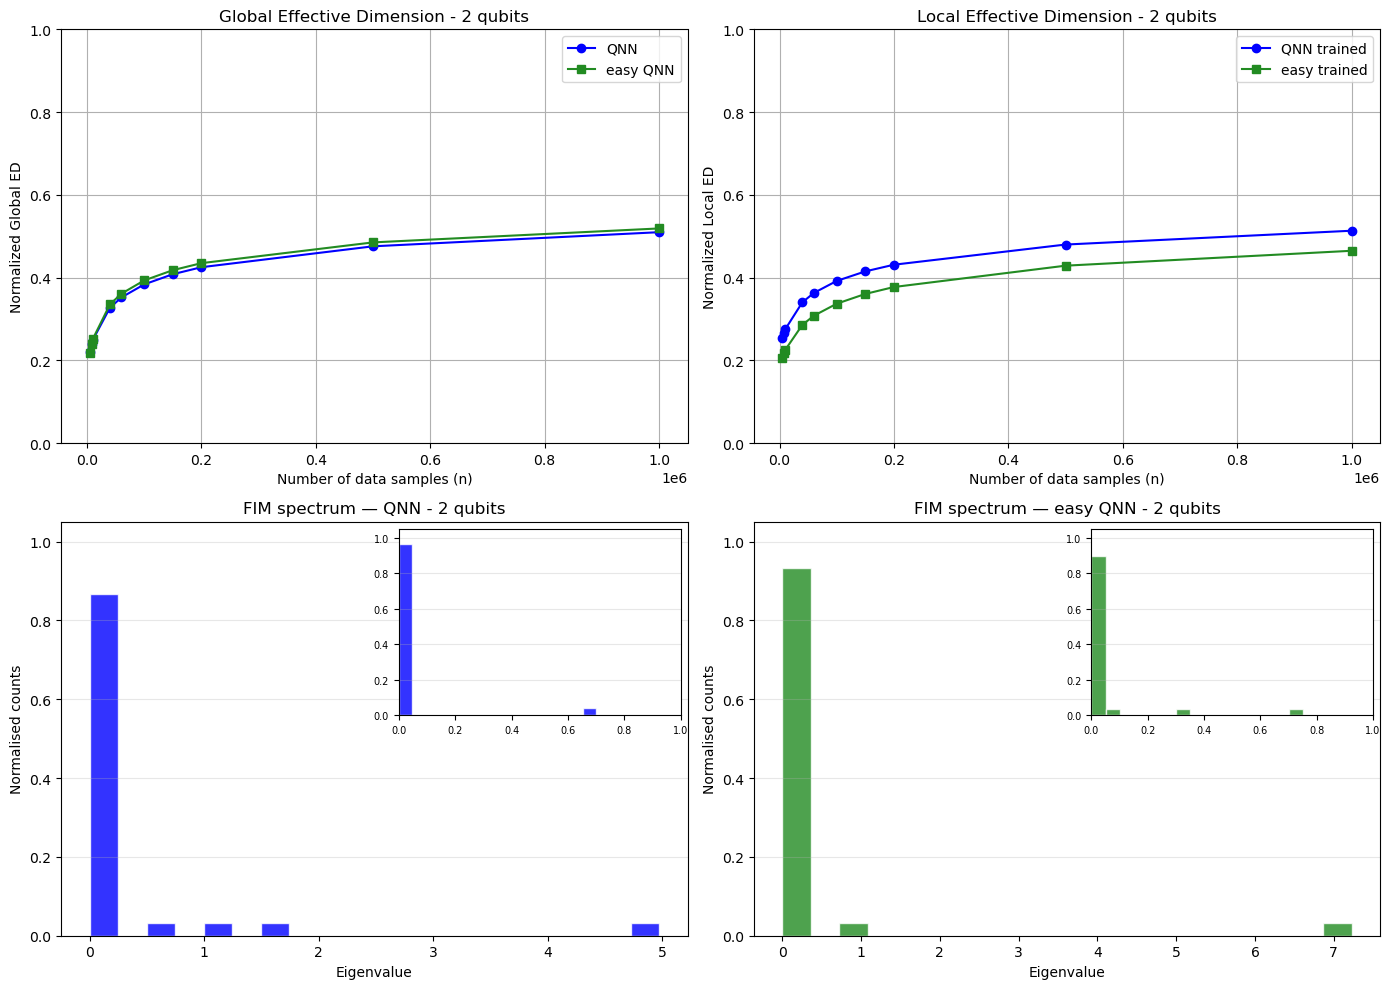

In [4]:
n = [5000, 8000, 10000, 40000, 60000, 100000, 150000, 200000, 500000, 1000000]

global_eff_qnn           = np.load('2_qubits/global_eff_qnn.pkl',            allow_pickle=True)
global_eff_easy          = np.load('2_qubits/global_eff_easy.pkl',           allow_pickle=True)
local_eff_trained_qnn    = np.load('2_qubits/local_eff_trained_qnn.pkl',     allow_pickle=True)
local_eff_trained_easy   = np.load('2_qubits/local_eff_trained_easy.pkl',    allow_pickle=True)
fim_trained_qnn          = np.load('2_qubits/fim_trained_qnn.pkl',           allow_pickle=True)
fim_trained_easy         = np.load('2_qubits/fim_trained_easy.pkl',          allow_pickle=True)

d = fim_trained_qnn.shape[0]
print(f'Results 2 qubits ----------------------------')
print(f'Global ED QNN       (n=5000): {global_eff_qnn[0]:.4f}  normalized: {global_eff_qnn[0]/d:.4f}')
print(f'Global ED easy      (n=5000): {global_eff_easy[0]:.4f}  normalized: {global_eff_easy[0]/d:.4f}')
print(f'Local trained ED QNN  (n=5000): {local_eff_trained_qnn[0]:.4f}  normalized: {local_eff_trained_qnn[0]/d:.4f}')
print(f'Local trained ED easy (n=5000): {local_eff_trained_easy[0]:.4f}  normalized: {local_eff_trained_easy[0]/d:.4f}')
print(f'FIM trace QNN     trained: {np.trace(fim_trained_qnn):.4f}')
print(f'FIM trace easy    trained: {np.trace(fim_trained_easy):.4f}')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Global ED
axes[0,0].plot(n, np.array(global_eff_qnn)  / d, marker='o', color='blue',        label='QNN')
axes[0,0].plot(n, np.array(global_eff_easy) / d, marker='s', color='forestgreen', label='easy QNN')
#axes[0,0].set_xscale('log')
axes[0,0].set_ylim([0, 1])
axes[0,0].set_xlabel('Number of data samples (n)')
axes[0,0].set_ylabel('Normalized Global ED')
axes[0,0].set_title('Global Effective Dimension - 2 qubits')
axes[0,0].legend()
axes[0,0].grid(True)

# Local ED
axes[0,1].plot(n, np.array(local_eff_trained_qnn)   / d, color='blue',        marker='o', label='QNN trained')
axes[0,1].plot(n, np.array(local_eff_trained_easy)  / d, color='forestgreen', marker='s', label='easy trained')
#axes[0,1].set_xscale('log')
axes[0,1].set_ylim([0, 1])
axes[0,1].set_xlabel('Number of data samples (n)')
axes[0,1].set_ylabel('Normalized Local ED')
axes[0,1].set_title('Local Effective Dimension - 2 qubits')
axes[0,1].legend()
axes[0,1].grid(True)

# FIM
plot_fim(axes[1,0], fim_trained_qnn,  label='QNN - 2 qubits',     color='blue')
plot_fim(axes[1,1], fim_trained_easy, label='easy QNN - 2 qubits', color='forestgreen')

plt.tight_layout()
plt.savefig("2_qubits.png")
plt.show()


/tmp/ipykernel_6710/3753283699.py:14: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


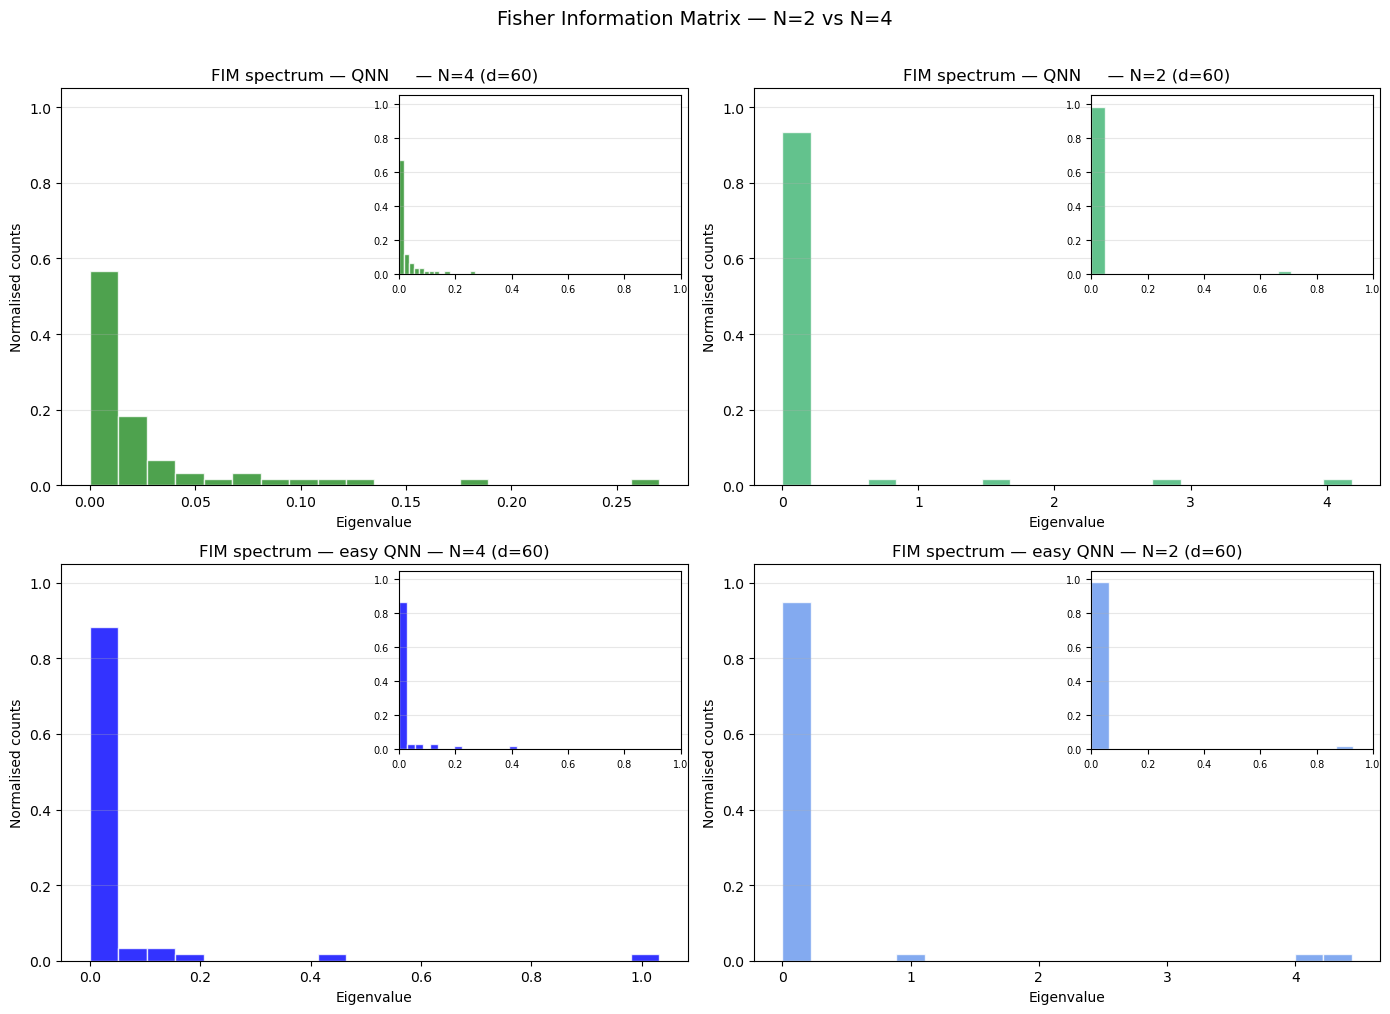

In [183]:
fim_qnn_4  = np.load('4_qb/fim_qnn.pkl',  allow_pickle=True)
fim_easy_4 = np.load('4_qb/fim_easy_qnn.pkl', allow_pickle=True)
fim_qnn_2  = np.load('2_qb/fim_qnn.pkl', allow_pickle=True)
fim_easy_2 = np.load('2_qb/fim_easy_qnn.pkl', allow_pickle=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

plot_fim(axes[0, 0], fim_qnn_4,  label='QNN     — N=4 (d=60)', color='forestgreen')
plot_fim(axes[0, 1], fim_qnn_2,  label='QNN     — N=2 (d=60)', color='mediumseagreen')
plot_fim(axes[1, 0], fim_easy_4, label='easy QNN — N=4 (d=60)', color='blue')
plot_fim(axes[1, 1], fim_easy_2, label='easy QNN — N=2 (d=60)', color='cornflowerblue')

plt.suptitle('Fisher Information Matrix — N=2 vs N=4', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('fim_comparison_N2_N4.png', dpi=300, bbox_inches='tight')
plt.show()

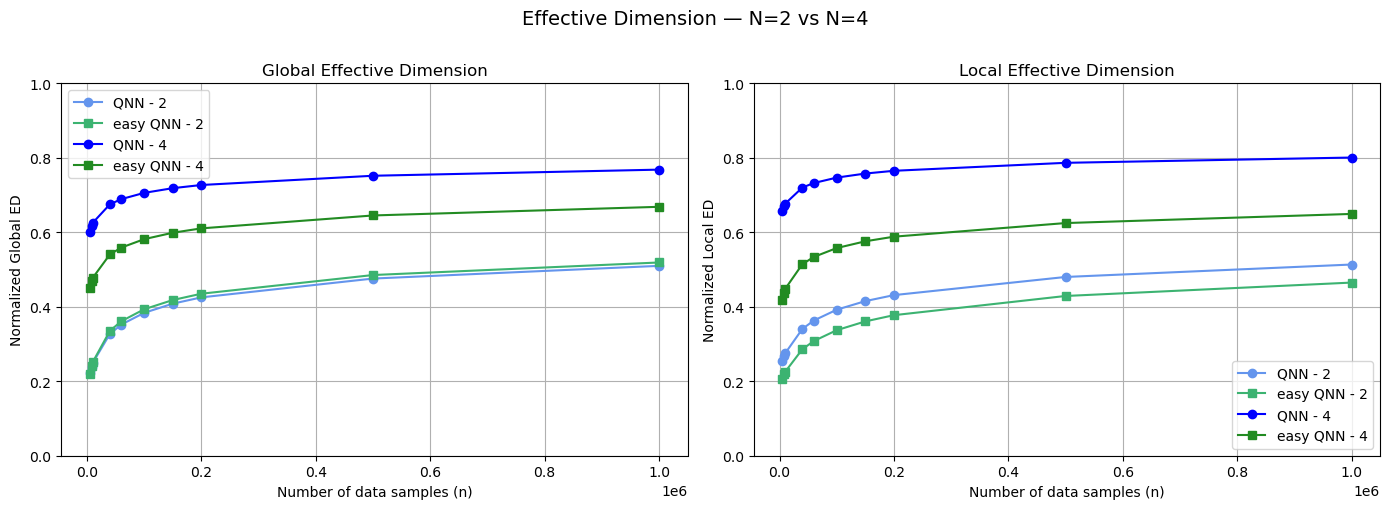

In [7]:
n = [5000, 8000, 10000, 40000, 60000, 100000, 150000, 200000, 500000, 1000000]
global_eff_qnn_2           = np.load('2_qubits/global_eff_qnn.pkl',            allow_pickle=True)
global_eff_easy_2          = np.load('2_qubits/global_eff_easy.pkl',           allow_pickle=True)
local_eff_trained_qnn_2    = np.load('2_qubits/local_eff_trained_qnn.pkl',     allow_pickle=True)
local_eff_trained_easy_2   = np.load('2_qubits/local_eff_trained_easy.pkl',    allow_pickle=True)
global_eff_qnn_4           = np.load('4_qubits/global_eff_qnn.pkl',            allow_pickle=True)
global_eff_easy_4          = np.load('4_qubits/global_eff_easy.pkl',           allow_pickle=True)
local_eff_trained_qnn_4    = np.load('4_qubits/local_eff_trained_qnn.pkl',     allow_pickle=True)
local_eff_trained_easy_4   = np.load('4_qubits/local_eff_trained_easy.pkl',    allow_pickle=True)
fim_qnn_4  = np.load('4_qubits/fim_trained_qnn.pkl',  allow_pickle=True)
fim_easy_4 = np.load('4_qubits/fim_trained_easy.pkl', allow_pickle=True)
fim_qnn_2  = np.load('2_qubits/fim_trained_qnn.pkl', allow_pickle=True)
fim_easy_2 = np.load('2_qubits/fim_trained_easy.pkl', allow_pickle=True)

d_2 = fim_qnn_2.shape[0]
d_4 = fim_qnn_4.shape[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5) )

axes[0].plot(n, np.array(global_eff_qnn_2)  / d_2, marker='o', color='cornflowerblue',        label='QNN - 2')
axes[0].plot(n, np.array(global_eff_easy_2) / d_2, marker='s', color='mediumseagreen', label='easy QNN - 2')
axes[0].plot(n, np.array(global_eff_qnn_4)  / d_4, marker='o', color='blue',        label='QNN - 4')
axes[0].plot(n, np.array(global_eff_easy_4) / d_4, marker='s', color='forestgreen', label='easy QNN - 4')
#axes[0].set_xscale('log')
axes[0].set_ylim([0, 1])
axes[0].set_xlabel('Number of data samples (n)')
axes[0].set_ylabel('Normalized Global ED')
axes[0].set_title('Global Effective Dimension')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(n, np.array(local_eff_trained_qnn_2)   / d_2, color='cornflowerblue',        marker='o', label='QNN - 2')
axes[1].plot(n, np.array(local_eff_trained_easy_2)  / d_2, color='mediumseagreen', marker='s', label='easy QNN - 2')
axes[1].plot(n, np.array(local_eff_trained_qnn_4)   / d_4, color='blue',        marker='o', label='QNN - 4')
axes[1].plot(n, np.array(local_eff_trained_easy_4)  / d_4, color='forestgreen', marker='s', label='easy QNN - 4')
#axes[1].set_xscale('log')
axes[1].set_ylim([0, 1])
axes[1].set_xlabel('Number of data samples (n)')
axes[1].set_ylabel('Normalized Local ED')
axes[1].set_title('Local Effective Dimension')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Effective Dimension — N=2 vs N=4', fontsize=14, y=1.01)

plt.tight_layout()
plt.savefig('ED_comparison_N2_N4.png', dpi=300, bbox_inches='tight')
plt.show()

# EFFECTIVE DIMENSION OF 3 Models

In [ ]:
def effective_dimension_global(fishers, n):
    d = fishers[0].shape[0]
    num_thetas = len(fishers)

    # average Fisher across all thetas, used only for the trace normalization
    F_avg = np.mean(fishers, axis=0)
    trace = np.trace(F_avg)

    kappa = n / (2 * np.pi * np.log(n))

    logdets = []
    for F in fishers:
        F_hat = d * F / trace
        M = np.eye(d) + kappa * F_hat
        sign, logdet = np.linalg.slogdet(M)
        logdets.append(0.5 * logdet)

    # logsumexp, done manually
    logdets = np.array(logdets)
    max_val = np.max(logdets)
    log_sum_exp = max_val + np.log(np.sum(np.exp(logdets - max_val)))

    d_eff = 2 * (log_sum_exp - np.log(num_thetas)) / np.log(kappa)
    return d_eff


# ---------------------------------------------------
# RUN: GLOBAL EFFECTIVE DIMENSION FOR THE CLASSICAL MODEL
# ---------------------------------------------------
CL_model = build_model2(input_lenght=4, depth=3, n_class=2)
d = CL_model.count_params()   # 60
m = 4

weights = np.random.uniform(-1, 1, size=(300, d))
inputs  = np.random.normal(0, 1, size=(100, m))

fishers = []
for t in range(weights.shape[0]):
    set_flat_weights(CL_model, weights[t], *get_shapes_sizes(CL_model))  # reuse from earlier
    F_t = compute_fisher_true(CL_model, inputs)
    fishers.append(F_t)
    if t % 50 == 0:
        print(f"done {t}/{weights.shape[0]}")

n_list = [1000, 3000, 5000, 8000, 10000, 40000, 60000, 100000, 150000, 200000, 500000, 1000000]

global_eff_cl_vs_n = [effective_dimension_global(fishers, n) for n in n_list]

for n, eff in zip(n_list, global_eff_cl_vs_n):
    print(f"n={n:>8}: Global ED CL = {eff:.4f}  normalized: {eff/d:.4f}")

with open("global_eff_cl_bin.pkl", "wb") as f:
    pickle.dump(global_eff_cl_vs_n, f)

Global ED QNN       (n=5000): 36.1946  normalized: 0.6032
Global ED easy      (n=5000): 26.6469  normalized: 0.4441
Global ED Cll       (n=5000): 0.4400  normalized: 0.0073


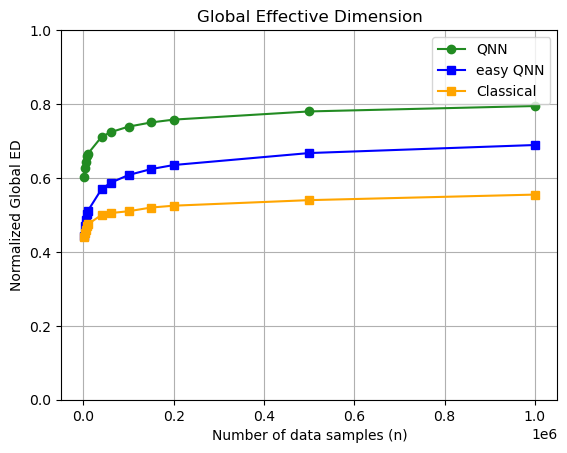

In [6]:
n = [1000,3000,5000, 8000, 10000, 40000, 60000, 100000, 150000, 200000, 500000, 1000000]
#global_eff_qnn           = np.load('global_eff_qnn.pkl',            allow_pickle=True)
#global_eff_easy          = np.load('global_eff_easy.pkl',           allow_pickle=True)
global_eff_qnn           = np.load('4_qb/global_eff_qnn.pkl',            allow_pickle=True)
global_eff_easy          = np.load('4_qb/global_eff_easy_qnn.pkl',           allow_pickle=True)
global_eff_cl            = np.load('global_eff_cl.pkl',                  allow_pickle=True)
fim_trained_qnn          = np.load('4_qb/fim_qnn.pkl',           allow_pickle=True)
d = fim_trained_qnn.shape[0]

print(f'Global ED QNN       (n=5000): {global_eff_qnn[0]:.4f}  normalized: {global_eff_qnn[0]/d:.4f}')
print(f'Global ED easy      (n=5000): {global_eff_easy[0]:.4f}  normalized: {global_eff_easy[0]/d:.4f}')
print(f'Global ED Cll       (n=5000): {global_eff_cl[0]:.4f}  normalized: {global_eff_cl[0]/d:.4f}')

fig, axes = plt.subplots(1, 1)

# Global ED
axes.plot(n, np.array(global_eff_qnn)/d, marker='o', color='forestgreen',        label='QNN')
axes.plot(n, np.array(global_eff_easy)/d, marker='s', color='blue', label='easy QNN')
axes.plot(n, np.array(global_eff_cl), marker='s', color='orange', label='Classical')
#axes.set_xscale('log')
axes.set_ylim([0, 1])
axes.set_xlabel('Number of data samples (n)')
axes.set_ylabel('Normalized Global ED')
axes.set_title('Global Effective Dimension')
axes.legend()
axes.grid(True)
plt.savefig("ED_models.png")
